In [1]:
import pandas as pd

data = {
    "Company": ["Coca Cola", "PepsiCo", "Nestle", "Starbucks", "McDonalds",
                "Unilever", "Danone", "Kraft Heinz", "Red Bull", "Monster"],
    "Revenue_Billion": [45.0, 86.0, 94.0, 32.0, 23.0, 60.0, 28.0, 26.0, 9.0, 6.0],
    "Employees": [79000, 315000, 275000, 383000, 200000, 148000, 100000, 38000, 15000, 3500],
    "Market": ["Beverages", "Snacks", "Food", "Coffee", "Fast Food",
               "Food", "Dairy", "Food", "Energy Drinks", "Energy Drinks"],
    "Customer_Reviews": [
        "Refreshing drinks and strong global brand",
        "Wide variety of snacks and beverages",
        "High quality food products worldwide",
        "Great coffee and customer experience",
        "Fast service and affordable meals",
        "Sustainable and diverse product range",
        "Healthy dairy products focus",
        "Classic food brands with strong presence",
        "High energy drinks popular among youth",
        "Strong brand in energy drink segment"
    ]
}

df = pd.DataFrame(data)
df.to_csv("Food_Beverage_Industry.csv", index=False)

df.head()

,Company,Revenue_Billion,Employees,Market,Customer_Reviews
0,Coca Cola,45.0,79000,Beverages,Refreshing drinks and strong global brand
1,PepsiCo,86.0,315000,Snacks,Wide variety of snacks and beverages
2,Nestle,94.0,275000,Food,High quality food products worldwide
3,Starbucks,32.0,383000,Coffee,Great coffee and customer experience
4,McDonalds,23.0,200000,Fast Food,Fast service and affordable meals


In [2]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select features
X = df[["Revenue_Billion", "Employees"]]

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

df

,Company,Revenue_Billion,Employees,Market,Customer_Reviews,Cluster
0,Coca Cola,45.0,79000,Beverages,Refreshing drinks and strong global brand,1
1,PepsiCo,86.0,315000,Snacks,Wide variety of snacks and beverages,2
2,Nestle,94.0,275000,Food,High quality food products worldwide,2
3,Starbucks,32.0,383000,Coffee,Great coffee and customer experience,0
4,McDonalds,23.0,200000,Fast Food,Fast service and affordable meals,1
5,Unilever,60.0,148000,Food,Sustainable and diverse product range,1
6,Danone,28.0,100000,Dairy,Healthy dairy products focus,1
7,Kraft Heinz,26.0,38000,Food,Classic food brands with strong presence,1
8,Red Bull,9.0,15000,Energy Drinks,High energy drinks popular among youth,1
9,Monster,6.0,3500,Energy Drinks,Strong brand in energy drink segment,1


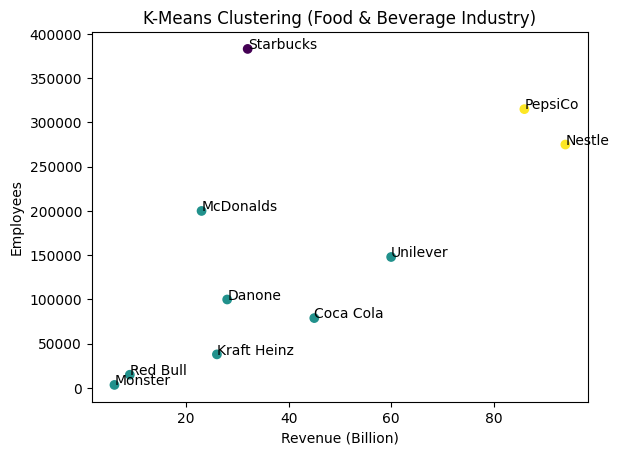

In [3]:
import matplotlib.pyplot as plt

plt.scatter(df["Revenue_Billion"], df["Employees"], c=df["Cluster"])
plt.xlabel("Revenue (Billion)")
plt.ylabel("Employees")
plt.title("K-Means Clustering (Food & Beverage Industry)")

for i, txt in enumerate(df["Company"]):
    plt.annotate(txt, (df["Revenue_Billion"][i], df["Employees"][i]))

plt.show()

In [4]:
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import re

nltk.download('stopwords')

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df["Clean_Reviews"] = df["Customer_Reviews"].apply(clean_text)

# TF-IDF
vectorizer = TfidfVectorizer(stop_words=stopwords.words('english'))
X_text = vectorizer.fit_transform(df["Clean_Reviews"])

print(X_text.shape)

(10, 38)


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
kmeans_text = KMeans(n_clusters=3, random_state=42)
df["Text_Cluster"] = kmeans_text.fit_predict(X_text)

df[["Company", "Text_Cluster"]]

,Company,Text_Cluster
0,Coca Cola,1
1,PepsiCo,2
2,Nestle,0
3,Starbucks,0
4,McDonalds,0
5,Unilever,0
6,Danone,0
7,Kraft Heinz,1
8,Red Bull,1
9,Monster,1


In [6]:
import numpy as np

terms = vectorizer.get_feature_names_out()

for i in range(3):
    print(f"\nCluster {i} keywords:")
    center = kmeans_text.cluster_centers_[i]
    top_words = [terms[ind] for ind in center.argsort()[-5:]]
    print(top_words)


Cluster 0 keywords:
['great', 'healthy', 'focus', 'dairy', 'products']

Cluster 1 keywords:
['drink', 'drinks', 'energy', 'brand', 'strong']

Cluster 2 keywords:
['youth', 'snacks', 'beverages', 'variety', 'wide']
